<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/04_06_Compare_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing Regularization Techniques: Jet Engine Thrust Degradation

When fitting models to data, we often face the danger of **overfitting**, especially when utilizing high-degree polynomials on noisy data.

To demonstrate this, we will model the **Thrust Degradation** of a jet engine over 4000 flight cycles. We assume that the true physical degradation behaves as a smooth quadratic curve ($f = x^2$). However, as an exercise, we will purposefully fit a severely overly complex **20-degree polynomial** to this noisy data.

We will compare four different regression techniques over 100 random noisy trials to see how they handle this severe overparameterization:

1.  `pinv`: Pseudo-inverse (Unregularized). Finds the exact mathematical minimum L2 norm solution, but is highly sensitive to noise.
2.  `lstsq`: SciPy Least Squares (Unregularized). Uses SVD or QR factorization. Behavior similar to pinv.
3.  **Lasso ($L_1$ Regularization)**: $\text{Minimize } ||Ax-b||_2^2 + \lambda ||x||_1$
    *   Adds an absolute value penalty to the coefficients.
    *   **Effect:** Aggressively forces "unimportant" polynomial coefficients to exactly zero, creating a clear, *sparse* model.
4.  **Ridge ($L_2$ Regularization)**: $\text{Minimize } ||Ax-b||_2^2 + \lambda ||x||_2^2$
    *   Adds a squared penalty to the coefficients.
    *   **Effect:** Shrinks all coefficients toward zero reducing model variance, but rarely makes them exactly zero.

The code from the textbook [1] was heavily refactored for clarity and framed within this aerospace context.

[1] https://github.com/kursatkara/databook_python/blob/master/CH04/CH04_SEC04_1_CompareRegression.ipynb

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn import linear_model

rcParams.update({'font.size': 14})
rcParams['axes.grid'] = True

In [15]:
# Number of data points
n_flights = 100

# Scaled thousands of flight cycles (0 to 4 thousand)
x_cycles = np.linspace(0, 4, n_flights)

# True physical thrust degradation (Smooth Parabola)
f_true_degradation = np.power(x_cycles, 2)

# Degree of the polynomial we will force to fit this data (massive overfitting!)
M_degree = 20

# Build the Vandermonde matrix: powers of x from x^1 up to x^20
A_matrix = np.zeros((n_flights, M_degree))
for j in range(M_degree):
    A_matrix[:, j] = np.power(x_cycles, j + 1) # Note: we exclude the intercept x^0 = 1 for this matrix

# We will run 100 trials, adding different random noise each time, to observe model variance.
trials = 100
# Matrices to store the 20 coefficients computed by each of the 4 methods across the 100 trials
coefs_pinv  = np.zeros((M_degree, trials))
coefs_lstsq = np.zeros((M_degree, trials))
coefs_lasso = np.zeros((M_degree, trials))
coefs_ridge = np.zeros((M_degree, trials))

# Regularization strength for Lasso and Ridge
#lambda_reg = 0.5
lambda_reg = 0.1

for j in range(trials):
    # Add random noise (Normal distribution, mean 0, std 1.0) to simulate sensor noise
    noisy_degradation = f_true_degradation + np.random.randn(n_flights) * 1.0

    # 1. Pseudo-inverse
    coefs_pinv[:, j] = np.linalg.pinv(A_matrix) @ noisy_degradation

    # 2. Least Squares
    coefs_lstsq[:, j] = np.linalg.lstsq(A_matrix, noisy_degradation, rcond=None)[0]

    # 3. Lasso (L1 penalty)
    # Exclude intercept so it purely regularizes the 20 polynomial terms
    lasso_model = linear_model.Lasso(alpha=lambda_reg, fit_intercept=False, max_iter=10000, tol=1e-3)
    lasso_model.fit(A_matrix, noisy_degradation)
    coefs_lasso[:, j] = lasso_model.coef_

    # 4. Ridge (L2 penalty)
    ridge_model = linear_model.Ridge(alpha=lambda_reg, fit_intercept=False)
    ridge_model.fit(A_matrix, noisy_degradation)
    coefs_ridge[:, j] = ridge_model.coef_

print("Finished fitting 20-degree polynomials over 100 noisy trials.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.443e+01, tolerance: 5.225e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.430e+01, tolerance: 5.435e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.278e+01, tolerance: 5.367e

Finished fitting 20-degree polynomials over 100 noisy trials.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.332e+01, tolerance: 5.317e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.536e+01, tolerance: 5.321e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.022e+01, tolerance: 5.393e

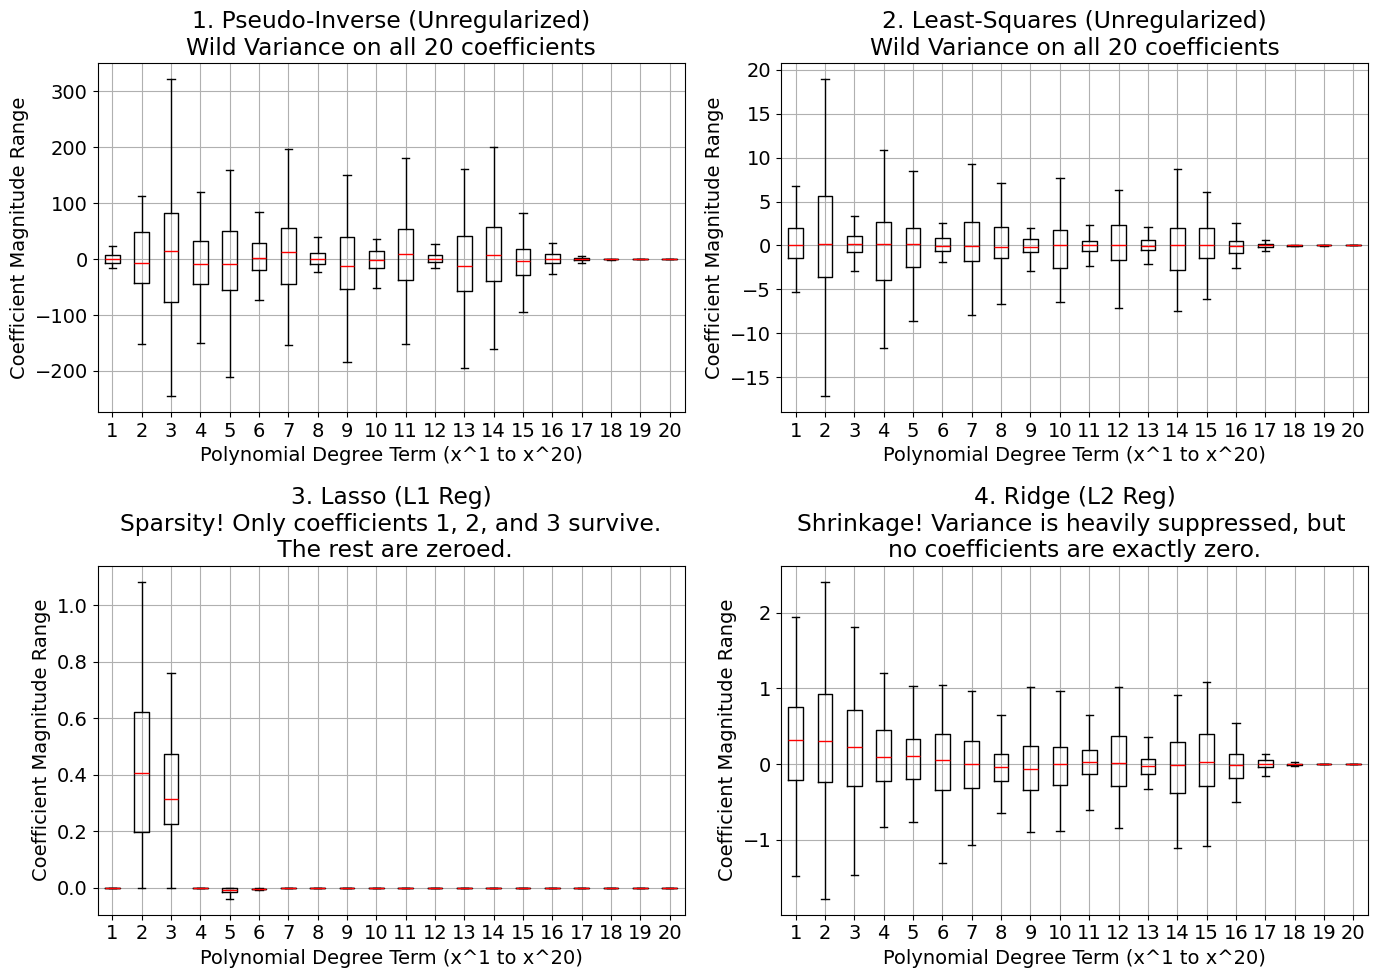

In [19]:
# Let's visualize the variability of the 20 coefficients across the 100 trials
plt.rcParams['figure.figsize'] = [14, 10]
fig, axs = plt.subplots(2, 2, sharey=False)
axs = axs.reshape(-1)

# Function to safely plot boxplots
boxplot_kwargs = dict(showfliers=False, medianprops=dict(color='red'))

axs[0].boxplot(coefs_pinv.T, **boxplot_kwargs)
axs[0].set_title('1. Pseudo-Inverse (Unregularized)\nWild Variance on all 20 coefficients')

axs[1].boxplot(coefs_lstsq.T, **boxplot_kwargs)
axs[1].set_title('2. Least-Squares (Unregularized)\nWild Variance on all 20 coefficients')

axs[2].boxplot(coefs_lasso.T, **boxplot_kwargs)
axs[2].set_title('3. Lasso (L1 Reg)\nSparsity! Only coefficients 1, 2, and 3 survive.\n The rest are zeroed.')

axs[3].boxplot(coefs_ridge.T, **boxplot_kwargs)
axs[3].set_title('4. Ridge (L2 Reg)\nShrinkage! Variance is heavily suppressed, but \nno coefficients are exactly zero.')

for ax in axs:
    ax.set_xlabel('Polynomial Degree Term (x^1 to x^20)')
    ax.set_ylabel('Coefficient Magnitude Range')

plt.tight_layout()
plt.show()

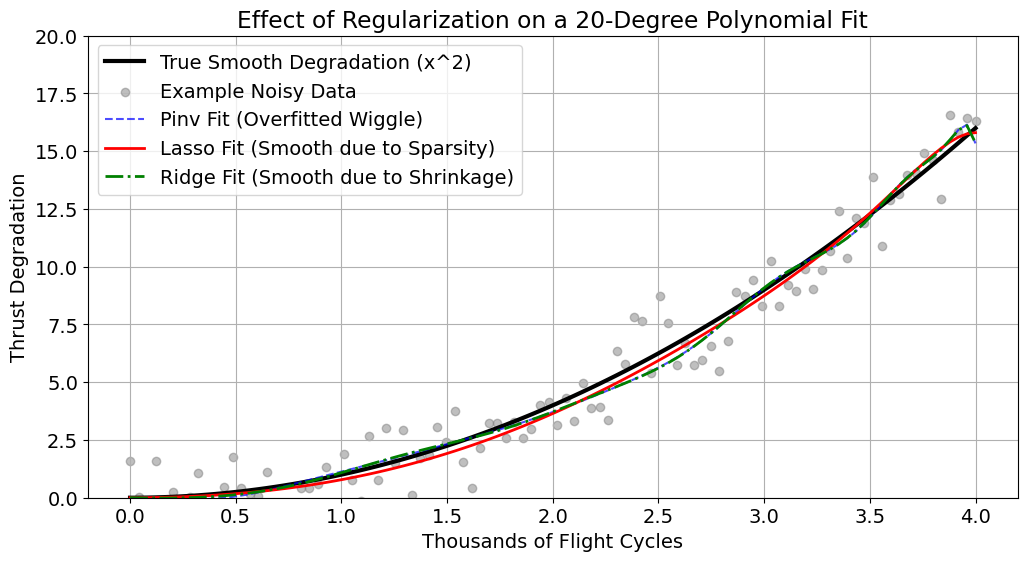

In [20]:
# Let's plot what these severely over-parameterized curves actually look like
# We will just evaluate Trial index 0 for visual clarity
trial_idx = 0

plt.figure(figsize=(12, 6))

# Underling truth and noisy data point for context
plt.plot(x_cycles, f_true_degradation, 'k-', linewidth=3, label='True Smooth Degradation (x^2)')
plt.scatter(x_cycles, f_true_degradation + np.random.randn(n_flights)*1.0, color='gray', alpha=0.5, label='Example Noisy Data')

# Reconstruct the curves from their calculated coefficients
curve_pinv  = A_matrix @ coefs_pinv[:, trial_idx]
curve_lstsq = A_matrix @ coefs_lstsq[:, trial_idx]
curve_lasso = A_matrix @ coefs_lasso[:, trial_idx]
curve_ridge = A_matrix @ coefs_ridge[:, trial_idx]

plt.plot(x_cycles, curve_pinv, '--', color='blue', alpha=0.7, label='Pinv Fit (Overfitted Wiggle)')
# Lstsq will look very similar to Pinv
plt.plot(x_cycles, curve_lasso, 'r-', linewidth=2, label='Lasso Fit (Smooth due to Sparsity)')
plt.plot(x_cycles, curve_ridge, 'g-.', linewidth=2, label='Ridge Fit (Smooth due to Shrinkage)')

plt.xlabel('Thousands of Flight Cycles')
plt.ylabel('Thrust Degradation')
plt.title('Effect of Regularization on a 20-Degree Polynomial Fit')
plt.ylim(0, 20)
plt.legend()
plt.show()

### Challenge Problem: Elastic Net Regularization
Lasso ($L_1$) creates sparsity, and Ridge ($L_2$) creates stable shrinkage. **Elastic Net** combines both penalties: $\text{Minimize } ||Ax-b||_2^2 + \lambda_1 ||x||_1 + \lambda_2 ||x||_2^2$. This is highly effective for engineering models where groups of variables are highly correlated. Your challenge: use `sklearn.linear_model.ElasticNet` with an `l1_ratio=0.5` across our 100 trials and plot its coefficient boxplot to compare against pure Lasso and Ridge.

In [ ]:
# YOUR CODE HERE
# 1. Initialize an array for ElasticNet coefficients
# 2. Using the existing 100 trials loop (or a new equivalent loop), fit ElasticNet(alpha=0.1, l1_ratio=0.5, fit_intercept=False)
# 3. Plot the boxplot of the resulting coefficients
from sklearn.linear_model import ElasticNet
# ...

<details>
<summary><b>Click to Reveal Solution</b></summary>

```python
from sklearn.linear_model import ElasticNet

coefs_elastic = np.zeros((M_degree, trials))

for j in range(trials):
    noisy_degradation = f_true_degradation + np.random.randn(n_flights) * 1.0
    
    # Fit Elastic Net
    enet = ElasticNet(alpha=lambda_reg, l1_ratio=0.5, fit_intercept=False, max_iter=10000, tol=1e-3)
    enet.fit(A_matrix, noisy_degradation)
    coefs_elastic[:, j] = enet.coef_

# Plotting
plt.figure(figsize=(8, 5))
plt.boxplot(coefs_elastic.T, showfliers=False, medianprops=dict(color='red'))
plt.title('Elastic Net (L1 + L2)\nNotice it balances sparsity (some exactly zero) with grouped shrinkage.')
plt.xlabel('Polynomial Degree Term')
plt.ylabel('Coefficient Magnitude')
plt.grid(True)
plt.show()
```
</details>